# Versao 6 - Classificacao Multiclasse com LSTM

## Objetivo deste notebook

Agora sim treinaremos um modelo sequencial. A ideia e usar uma `LSTM` para ler a serie temporal completa (ja reamostrada para comprimento fixo) e devolver uma probabilidade para cada uma das classes `0` a `9`.

## O que o modelo faz?

Em termos conceituais:

```text
serie temporal -> LSTM -> vetor latente -> camada densa -> softmax -> classe 0..9
```

Isso significa que a `LSTM` tentara aprender **assinaturas temporais** das classes.

## O que vamos medir?

Como a base e desbalanceada, nao vamos olhar apenas `accuracy`. Tambem vamos medir:

- `macro-F1`
- `balanced accuracy`
- `matriz de confusao`

Em problemas multiclasse desbalanceados, essas metricas costumam ser mais informativas do que a acuracia isolada.

## Resultados Da Ultima Execucao Registrada

Os artefatos atuais em `artifacts/reports_v6/classificacao_v6_artigo/lstm/` mostram:

- melhor epoca: `22`
- validacao da `LSTM`: `accuracy = 0.9311`, `macro-F1 = 0.9070`, `balanced accuracy = 0.9027`
- teste da `LSTM`: `accuracy = 0.9433`, `macro-F1 = 0.9185`, `balanced accuracy = 0.9367`
- classes mais dificeis no teste: classe `7` com `F1 = 0.7778` e `recall = 1.0000`; classe `2` com `F1 = 0.8333` e `recall = 1.0000`; classe `4` com `F1 = 0.8776` e `recall = 0.8269`

Isso e importante para a leitura do notebook: a rede recorrente teve desempenho forte, mas ainda apresentou fragilidades localizadas em algumas classes menos estaveis.

In [12]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Este bloco torna o notebook robusto ao diretorio atual.
# Se o notebook estiver sendo executado de dentro de `versao6`,
# o projeto real estara um nivel acima.
ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao6" else ROOT

# Adicionamos a raiz do projeto ao sys.path para conseguir importar
# `versao6.pipeline_v6` e demais modulos auxiliares.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [13]:
from versao6.pipeline_v6 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    load_bundle,
    load_lstm_classifier,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_lstm_classes,
    train_lstm_classifier,
)

RUN_NAME = "classificacao_v6_artigo"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v6" / RUN_NAME
LSTM_OUTPUT_DIR = RUN_DIR / "lstm"

bundle = load_bundle(RUN_DIR / "bundle_v6.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
val_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

In [14]:
# Hiperparametros principais da rede.
# Mantivemos os nomes explicitos para facilitar estudo.
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.20
BIDIRECTIONAL = True
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 6
RANDOM_STATE = 42

## Treinamento

A rotina abaixo:

1. monta a rede;
2. aplica pesos de classe na `CrossEntropyLoss`;
3. monitora `macro-F1` na validacao;
4. salva o melhor checkpoint automaticamente.

Para iniciantes: o checkpoint "melhor" nao e necessariamente o da ultima epoca, mas sim o que teve melhor desempenho de validacao.

In [15]:
lstm_summary = train_lstm_classifier(
    X_train=train_arrays["X_seq"],
    y_train=train_arrays["y"],
    X_val=val_arrays["X_seq"],
    y_val=val_arrays["y"],
    output_dir=LSTM_OUTPUT_DIR,
    class_labels=bundle.class_labels,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    random_state=RANDOM_STATE,
)

lstm_summary

LSTMTrainingSummary(model_name='lstm_multiclasse', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v6/classificacao_v6_artigo/lstm/lstm_multiclasse_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v6/classificacao_v6_artigo/lstm/lstm_multiclasse_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v6/classificacao_v6_artigo/lstm/lstm_multiclasse_history.csv', best_epoch=22, best_val_macro_f1=0.9069688492404415, best_val_accuracy=0.9311377245508982, best_val_balanced_accuracy=0.9027372575278093)

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
23,24,0.00050,0.195487,0.930083,0.918483,0.935751,0.913174,0.888676,0.899031
24,25,0.00050,0.169330,0.933291,0.912894,0.934483,0.925150,0.900691,0.904510
25,26,0.00050,0.156669,0.932008,0.918220,0.935879,0.928144,0.897901,0.902030
26,27,0.00025,0.153831,0.946761,0.927934,0.939447,0.919162,0.884780,0.891148
27,28,0.00025,0.164080,0.940346,0.922732,0.943211,0.922156,0.895027,0.901664


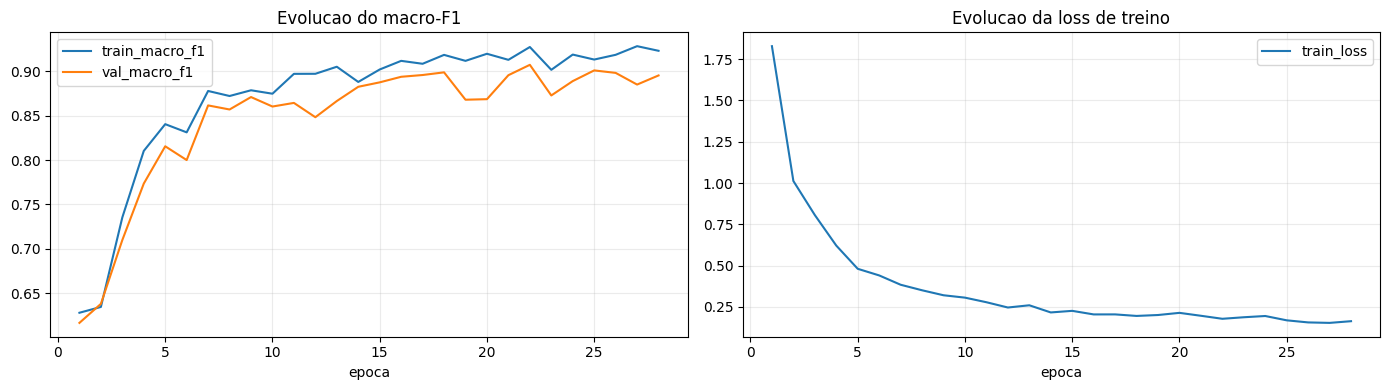

In [16]:
# O historico de treino ajuda muito a interpretar a convergencia.
history_df = pd.read_csv(lstm_summary.history_path)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
axes[0].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
axes[0].set_title("Evolucao do macro-F1")
axes[0].set_xlabel("epoca")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[1].set_title("Evolucao da loss de treino")
axes[1].set_xlabel("epoca")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Avaliacao do melhor checkpoint

Depois do treino, carregamos o melhor modelo salvo e avaliamos em:

- validacao, para confirmar o checkpoint;
- teste, para medir generalizacao fora da amostra.

In [17]:
lstm_model = load_lstm_classifier(lstm_summary.config_path)

val_pred = predict_lstm_classes(lstm_model, val_arrays["X_seq"])
test_pred = predict_lstm_classes(lstm_model, test_arrays["X_seq"])

val_eval = evaluate_predictions(val_arrays["y"], val_pred, class_labels=bundle.class_labels)
test_eval = evaluate_predictions(test_arrays["y"], test_pred, class_labels=bundle.class_labels)

comparison_df = build_metrics_table(
    {
        "lstm_validation": val_eval,
        "lstm_test": test_eval,
    }
)
comparison_df

,modelo,accuracy,macro_f1,balanced_accuracy
0,lstm_test,0.943284,0.918522,0.936684
1,lstm_validation,0.931138,0.906969,0.902737


In [18]:
# Aqui reunimos os numeros mais importantes em um formato
# mais interpretavel para leitura academica.
best_history_row = history_df.loc[history_df["epoch"] == lstm_summary.best_epoch].iloc[0]
metrics_focus_df = pd.DataFrame(
    {
        "etapa": ["validacao", "teste"],
        "accuracy": [val_eval["accuracy"], test_eval["accuracy"]],
        "macro_f1": [val_eval["macro_f1"], test_eval["macro_f1"]],
        "balanced_accuracy": [
            val_eval["balanced_accuracy"],
            test_eval["balanced_accuracy"],
        ],
    }
)
display(metrics_focus_df)

generalization_df = pd.DataFrame(
    {
        "indicador": [
            "melhor epoca",
            "macro_f1_treino_na_melhor_epoca",
            "macro_f1_validacao_na_melhor_epoca",
            "gap_treino_validacao",
        ],
        "valor": [
            int(lstm_summary.best_epoch),
            float(best_history_row["train_macro_f1"]),
            float(best_history_row["val_macro_f1"]),
            float(best_history_row["train_macro_f1"] - best_history_row["val_macro_f1"]),
        ],
    }
)
display(generalization_df)

,etapa,accuracy,macro_f1,balanced_accuracy
0,validacao,0.931138,0.906969,0.902737
1,teste,0.943284,0.918522,0.936684


,indicador,valor
0,melhor epoca,22.000000
1,macro_f1_treino_na_melhor_epoca,0.926983
2,macro_f1_validacao_na_melhor_epoca,0.906969
3,gap_treino_validacao,0.020014


In [19]:
# Exportamos os resultados para que o notebook das baselines
# possa carregar as metricas da LSTM depois.
export_evaluation_artifacts(val_eval, LSTM_OUTPUT_DIR, "lstm_validation")
export_evaluation_artifacts(test_eval, LSTM_OUTPUT_DIR, "lstm_test")

# Relatorio detalhado por classe no conjunto de teste.
display(test_eval["classification_report_df"])

,label,precision,recall,f1-score,support
0,0,0.906250,0.977528,0.940541,89.000000
1,1,1.000000,0.800000,0.888889,20.000000
2,2,0.714286,1.000000,0.833333,5.000000
3,3,1.000000,0.937500,0.967742,16.000000
4,4,0.934783,0.826923,0.877551,52.000000
5,5,0.985507,1.000000,0.992701,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.636364,1.000000,0.777778,7.000000
8,8,1.000000,0.857143,0.923077,14.000000
9,9,1.000000,0.967742,0.983607,31.000000


In [20]:
# Para enxergar melhor onde a rede foi bem e onde teve dificuldade,
# separamos apenas as linhas das classes reais.
per_class_test_df = (
    test_eval["classification_report_df"]
    .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
    .copy()
)
per_class_test_df["label"] = per_class_test_df["label"].astype(int)
per_class_test_df = per_class_test_df.sort_values(["f1-score", "recall", "precision"])
display(per_class_test_df)

,label,precision,recall,f1-score,support
7,7,0.636364,1.000000,0.777778,7.0
2,2,0.714286,1.000000,0.833333,5.0
4,4,0.934783,0.826923,0.877551,52.0
1,1,1.000000,0.800000,0.888889,20.0
8,8,1.000000,0.857143,0.923077,14.0
0,0,0.906250,0.977528,0.940541,89.0
3,3,1.000000,0.937500,0.967742,16.0
9,9,1.000000,0.967742,0.983607,31.0
5,5,0.985507,1.000000,0.992701,68.0
6,6,1.000000,1.000000,1.000000,33.0


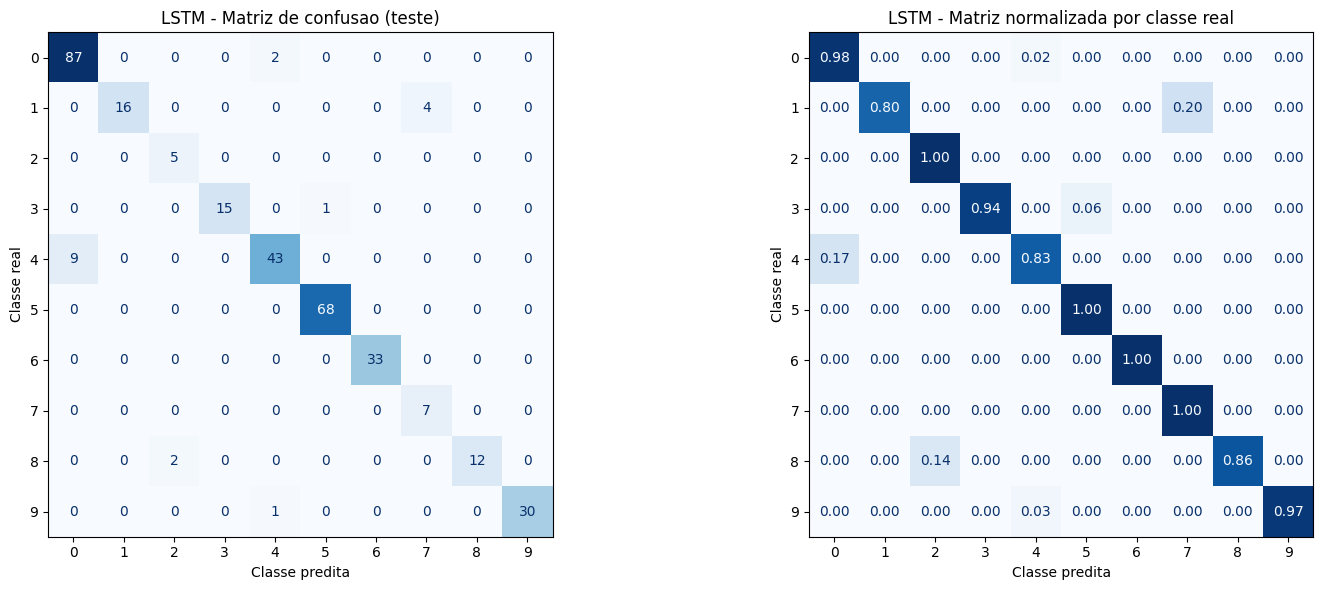

In [21]:
# Duas matrizes: uma absoluta e outra normalizada.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize=None,
    title="LSTM - Matriz de confusao (teste)",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize="true",
    title="LSTM - Matriz normalizada por classe real",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

In [22]:
# Esta celula imprime uma leitura textual com os numeros reais do experimento.
weakest_rows = per_class_test_df.head(3)

print("Leitura interpretativa da LSTM")
print()
print(
    f"No conjunto de teste, a LSTM atingiu accuracy = {test_eval['accuracy']:.4f}, "
    f"macro-F1 = {test_eval['macro_f1']:.4f} e balanced accuracy = {test_eval['balanced_accuracy']:.4f}."
)
print(
    f"A melhor epoca foi a {int(lstm_summary.best_epoch)}, com macro-F1 de validacao "
    f"igual a {val_eval['macro_f1']:.4f}."
)
print(
    f"O gap entre macro-F1 de treino e validacao na melhor epoca foi de "
    f"{best_history_row['train_macro_f1'] - best_history_row['val_macro_f1']:.4f}, "
    "o que sugere alguma diferenca entre ajuste e generalizacao, mas nao um sobreajuste explosivo."
)
print()
print("As classes com menor F1 no teste foram:")
for _, row in weakest_rows.iterrows():
    print(
        f"- classe {int(row['label'])}: precision = {row['precision']:.4f}, "
        f"recall = {row['recall']:.4f}, f1 = {row['f1-score']:.4f}, support = {int(row['support'])}"
    )
print()
print(
    "Em termos didaticos, isso indica que a rede aprendeu bem o problema como um todo, "
    "mas ainda encontra dificuldade em classes mais raras ou com assinaturas temporais "
    "mais proximas entre si."
)

Leitura interpretativa da LSTM

No conjunto de teste, a LSTM atingiu accuracy = 0.9433, macro-F1 = 0.9185 e balanced accuracy = 0.9367.
A melhor epoca foi a 22, com macro-F1 de validacao igual a 0.9070.
O gap entre macro-F1 de treino e validacao na melhor epoca foi de 0.0200, o que sugere alguma diferenca entre ajuste e generalizacao, mas nao um sobreajuste explosivo.

As classes com menor F1 no teste foram:
- classe 7: precision = 0.6364, recall = 1.0000, f1 = 0.7778, support = 7
- classe 2: precision = 0.7143, recall = 1.0000, f1 = 0.8333, support = 5
- classe 4: precision = 0.9348, recall = 0.8269, f1 = 0.8776, support = 52

Em termos didaticos, isso indica que a rede aprendeu bem o problema como um todo, mas ainda encontra dificuldade em classes mais raras ou com assinaturas temporais mais proximas entre si.


## Leitura didatica dos resultados

Ao interpretar o desempenho da `LSTM`, pense nas perguntas abaixo:

1. O `macro-F1` esta muito abaixo da `accuracy`?
   Isso pode indicar que a rede acerta bem as classes grandes, mas erra as raras.
2. A `balanced accuracy` esta coerente com o `macro-F1`?
   Isso ajuda a avaliar se o desempenho esta mais equilibrado entre as classes.
3. Quais classes a matriz de confusao mais mistura?
   Esse ponto e central para diagnostico do modelo.

Nesta execucao da `versao6`, a leitura preliminar ja aponta um fato importante: a `LSTM` foi forte, mas nao perfeita. O desempenho agregado ficou alto, porem algumas classes, como `4` e `7`, permaneceram mais sensiveis a confusoes. No notebook seguinte, vamos verificar se as baselines tabulares conseguem explorar melhor esse problema.